# INSTALL & IMPORT LIBRARIES

In [1]:
import sys
!{sys.executable} -m pip install pytorch-tabnet xgboost imbalanced-learn shap seaborn \
    --trusted-host files.pythonhosted.org \
    --trusted-host pypi.org \
    --trusted-host pypi.python.org -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
from imblearn.over_sampling import SMOTE
import shap
import torch

In [3]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('Semua library berhasil diimport!')
print(f'   PyTorch version  : {torch.__version__}')
print(f'   Pandas version   : {pd.__version__}')

Semua library berhasil diimport!
   PyTorch version  : 2.13.0
   Pandas version   : 3.0.3


---
# LOAD & MERGE DATASET

In [4]:
features_df = pd.read_csv('ecommerce_customer_features.csv')
targets_df  = pd.read_csv('ecommerce_customer_targets.csv')

print(' Struktur file sebelum merge:')
print(f'   features_df : {features_df.shape[0]:,} baris, {features_df.shape[1]} kolom')
print(f'   targets_df  : {targets_df.shape[0]:,} baris, {targets_df.shape[1]} kolom')
print(f'\n   Kolom features : {list(features_df.columns)}')
print(f'   Kolom targets  : {list(targets_df.columns)}')

 Struktur file sebelum merge:
   features_df : 6,000 baris, 15 kolom
   targets_df  : 6,000 baris, 2 kolom

   Kolom features : ['Customer_ID', 'account_age_months', 'avg_order_value', 'total_orders', 'days_since_last_purchase', 'discount_usage_rate', 'return_rate', 'customer_support_tickets', 'loyalty_member', 'browsing_frequency_per_week', 'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score', 'satisfaction_score', 'price_sensitivity_index']
   Kolom targets  : ['Customer_ID', 'churned']


In [5]:
df = pd.merge(features_df, targets_df, on='Customer_ID', how='inner')

df.drop(columns=["churned"]).to_csv("data_ecommerce_customer.csv", index=False)

print('Merge berhasil!')
print(f'   Jumlah baris  : {df.shape[0]:,}')
print(f'   Jumlah kolom  : {df.shape[1]}')
print(f'   Missing values: {df.isnull().sum().sum()}')

df.head()

Merge berhasil!
   Jumlah baris  : 6,000
   Jumlah kolom  : 16
   Missing values: 0


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


In [6]:
# Memilih seluruh kolom numerik dari dataframe hasil merge
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

# Mengecualikan kolom target churned
numeric_cols = [
    col for col in numeric_cols
    if col != 'churned'
]

# Menyimpan hasil pengecekan outlier
outlier_results = []

for col in numeric_cols:
    # Menghitung kuartil pertama dan ketiga
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Menghitung Interquartile Range
    IQR = Q3 - Q1

    # Menentukan batas outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menghitung jumlah outlier
    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    # Menghitung persentase outlier
    outlier_percentage = (
        outlier_count / len(df) * 100
    )

    outlier_results.append({
        'Feature': col,
        'Lower Bound': round(lower_bound, 3),
        'Upper Bound': round(upper_bound, 3),
        'Outlier Count': int(outlier_count),
        'Outlier Percentage (%)': round(
            outlier_percentage,
            2
        )
    })

# Mengubah hasil menjadi dataframe
outlier_results = pd.DataFrame(outlier_results)

# Mengurutkan fitur berdasarkan jumlah outlier
outlier_results = outlier_results.sort_values(
    by='Outlier Count',
    ascending=False
).reset_index(drop=True)

print('Hasil Pemeriksaan Outlier:')
display(outlier_results)

Hasil Pemeriksaan Outlier:


,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,customer_support_tickets,-1.500,2.500,414,6.90
1,days_since_last_purchase,-39.000,89.000,294,4.90
2,avg_order_value,-39.715,184.925,278,4.63
3,return_rate,-0.098,0.222,212,3.53
4,total_orders,-17.000,31.000,186,3.10
5,engagement_score,1.305,8.705,171,2.85
6,satisfaction_score,4.800,11.520,94,1.57
7,price_sensitivity_index,1.200,7.600,43,0.72
8,discount_usage_rate,-0.176,0.724,40,0.67
9,product_review_score_avg,1.640,6.200,25,0.42


---
# EDA (Exploratory Data Analysis)

In [9]:
print('Informasi Dataset:')
print(df.info())

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   str    
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   str    
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfacti

In [10]:
df.describe().round(2)

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
mean,30.81,80.49,8.57,29.60,0.29,0.07,0.86,3.08,0.60,3.88,4.88,8.07,4.51
std,17.36,55.04,9.89,29.45,0.16,0.07,0.98,1.89,0.20,0.78,1.48,1.24,1.15
min,1.00,10.00,1.00,0.00,0.00,0.00,0.00,0.00,0.03,1.00,1.00,2.30,1.00
25%,16.00,44.52,1.00,9.00,0.16,0.02,0.00,1.60,0.46,3.35,4.08,7.32,3.60
50%,31.00,67.22,5.00,20.00,0.26,0.05,1.00,3.00,0.62,3.92,5.12,8.23,4.40
75%,46.00,100.68,13.00,41.00,0.39,0.10,1.00,4.40,0.76,4.49,5.93,9.00,5.20
max,60.00,1006.53,85.00,261.00,0.90,0.49,6.00,10.30,1.00,5.00,8.72,10.00,8.60


In [11]:
print('Distribusi Target (churned):')
counts = df['churned'].value_counts()
pct    = df['churned'].value_counts(normalize=True).round(4) * 100
print(pd.DataFrame({'Jumlah': counts, 'Persentase (%)': pct}))

Distribusi Target (churned):
         Jumlah  Persentase (%)
churned                        
No         5071           84.52
Yes         929           15.48


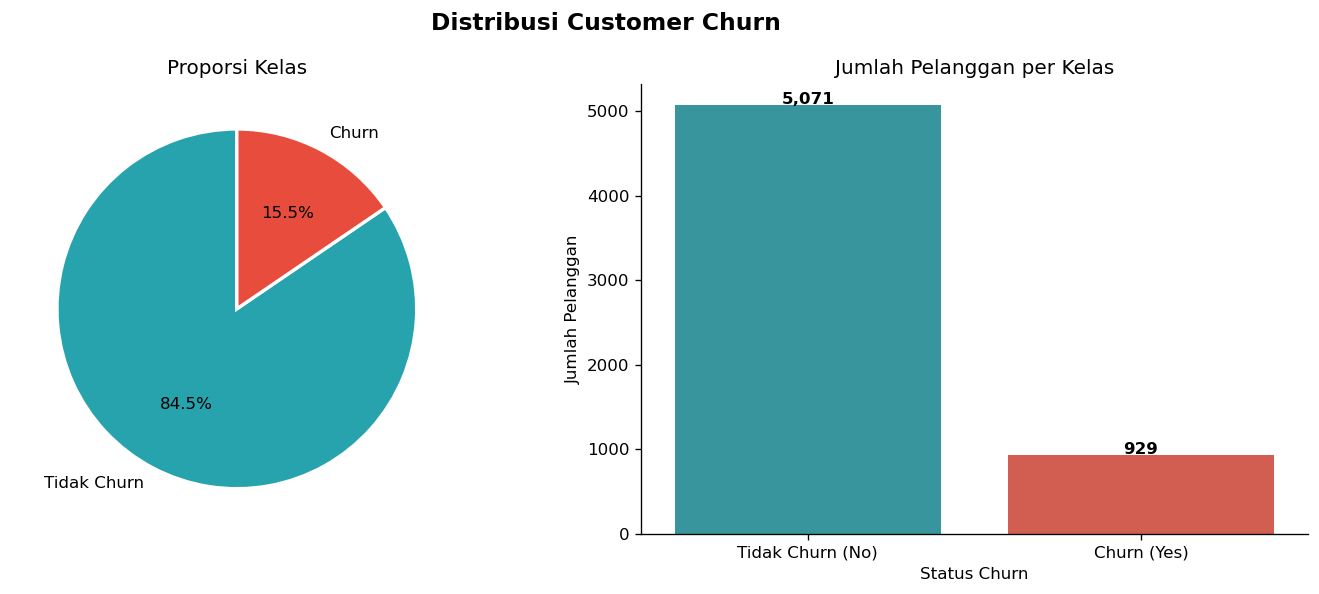

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Customer Churn', fontsize=14, fontweight='bold')

colors = ["#27a3ae", '#e74c3c']
axes[0].pie(
    counts, labels=['Tidak Churn', 'Churn'],
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporsi Kelas')

sns.countplot(x='churned', data=df,
              palette={'No': "#27a3ae", 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Jumlah Pelanggan per Kelas')
axes[1].set_xlabel('Status Churn')
axes[1].set_ylabel('Jumlah Pelanggan')
axes[1].set_xticklabels(['Tidak Churn (No)', 'Churn (Yes)'])
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height() + 20),
                     ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_eda_distribusi_churn.png', dpi=150, bbox_inches='tight')
plt.show()

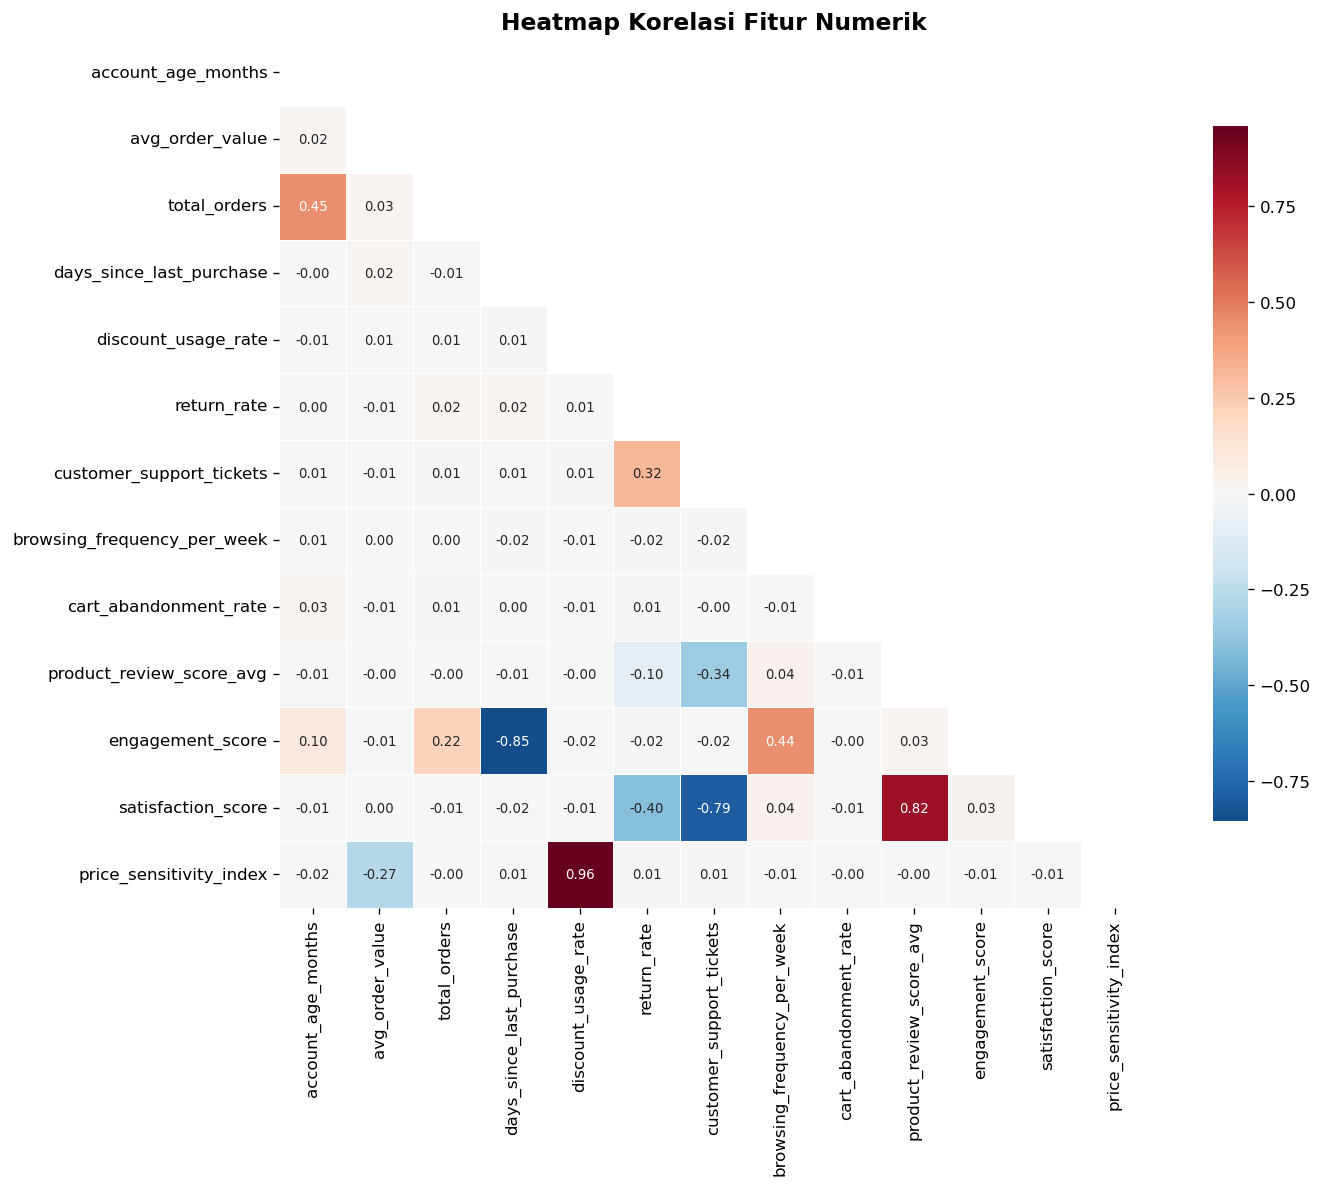

In [13]:
fig, ax = plt.subplots(figsize=(13, 10))
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, ax=ax,
    annot_kws={'size': 8}, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_eda_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

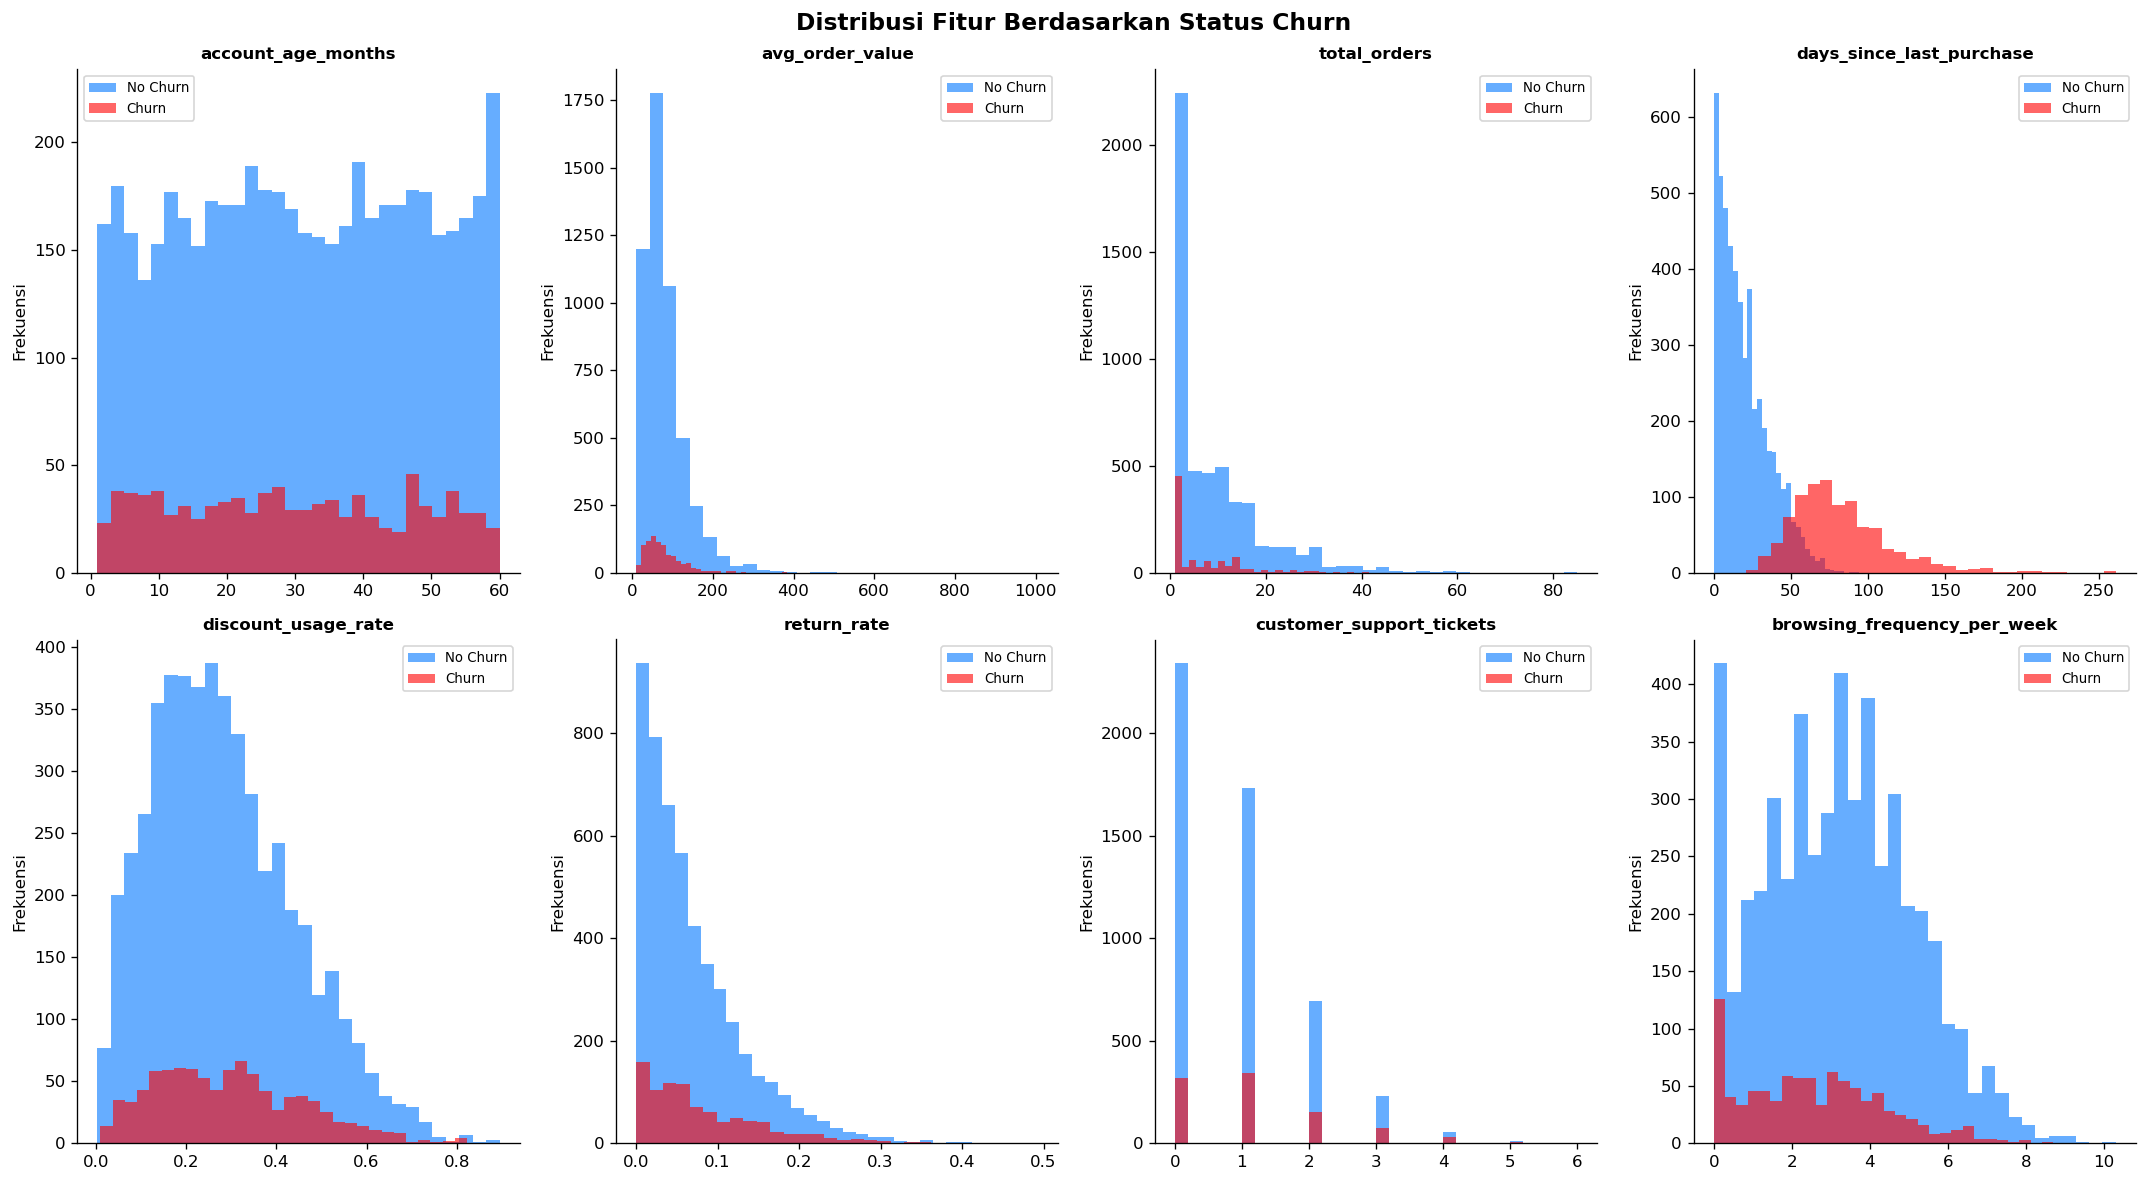

In [14]:
fitur_plot = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in ['CustomerID']
][:8]  # ambil 8 fitur pertama

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Distribusi Fitur Berdasarkan Status Churn',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(fitur_plot):
    for label, color, nama in [
        ('No',  "#0077FF", 'No Churn'),
        ('Yes', "#FF0000", 'Churn')
    ]:
        subset = df[df['churned'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=nama)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('03_eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PREPROCESSING

In [15]:
df_proc = df.copy()

if 'Customer_ID' in df_proc.columns:
    df_proc.drop(columns=['Customer_ID'], inplace=True)
    print('[DROP] Kolom Customer_ID dihapus')

[DROP] Kolom Customer_ID dihapus


In [16]:
# Encode kolom kategorikal
#le = LabelEncoder()
#cat_cols = df_proc.select_dtypes(include=['object']).columns.tolist()
#cat_cols = [c for c in cat_cols if c != 'churned']

#for col in cat_cols:
#    df_proc[col] = le.fit_transform(df_proc[col])
#    print(f'[ENCODE] {col} → {dict(enumerate(le.classes_))}')
# Encode target
#df_proc['churned'] = le.fit_transform(df_proc['churned'])
#print('[ENCODE] churned → 0=Tidak Churn, 1=Churn') 

In [17]:
# Encode kolom kategorikal
cat_cols = df_proc.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'churned']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col])
    encoders[col] = le
    print(f"ENCODE {col}: {dict(enumerate(le.classes_))}")

# Encode target
le_target = LabelEncoder()
df_proc['churned'] = le_target.fit_transform(df_proc['churned'])
encoders['churned'] = le_target
print('[ENCODE] churned → 0=Tidak Churn, 1=Churn')

import joblib

joblib.dump(encoders, "encoder.pkl")

ENCODE loyalty_member: {0: 'No', 1: 'Yes'}
[ENCODE] churned → 0=Tidak Churn, 1=Churn


['encoder.pkl']

In [18]:
# Memisahkan X dan y
X = df_proc.drop(columns=['churned'])
y = df_proc['churned']
feature_names = X.columns.tolist()

print(f'\nPreprocessing selesai')
print(f'   Jumlah fitur : {len(feature_names)}')
print(f'   Fitur        : {feature_names}')

df.head()


Preprocessing selesai
   Jumlah fitur : 14
   Fitur        : ['account_age_months', 'avg_order_value', 'total_orders', 'days_since_last_purchase', 'discount_usage_rate', 'return_rate', 'customer_support_tickets', 'loyalty_member', 'browsing_frequency_per_week', 'cart_abandonment_rate', 'product_review_score_avg', 'engagement_score', 'satisfaction_score', 'price_sensitivity_index']


,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No


---
TRAIN-TEST SPLIT

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split selesai')
print(f'   Data latih : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Data uji   : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'   Distribusi train : {dict(y_train.value_counts())}')
print(f'   Distribusi test  : {dict(y_test.value_counts())}')

Train-Test Split selesai
   Data latih : 4,800 baris (80%)
   Data uji   : 1,200 baris (20%)
   Distribusi train : {0: np.int64(4057), 1: np.int64(743)}
   Distribusi test  : {0: np.int64(1014), 1: np.int64(186)}


---
SMOTE (Synthetic Minority Oversampling Technique)

In [20]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

before = dict(y_train.value_counts())
after  = dict(pd.Series(y_train_sm).value_counts())

print('SMOTE selesai')
print(f'   Sebelum SMOTE : {before}')
print(f'   Sesudah SMOTE : {after}')
print(f'   Data latih bertambah dari {len(y_train):,} → {len(y_train_sm):,} baris')

SMOTE selesai
   Sebelum SMOTE : {0: np.int64(4057), 1: np.int64(743)}
   Sesudah SMOTE : {0: np.int64(4057), 1: np.int64(4057)}
   Data latih bertambah dari 4,800 → 8,114 baris


In [21]:
from collections import Counter
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nSMOTE")
print(f"Kelas 0: {Counter(y_train_sm)[0]} | Kelas 1: {Counter(y_train_sm)[1]}")
print(f"Total data: {len(y_train_sm)}")


SMOTE
Kelas 0: 4057 | Kelas 1: 4057
Total data: 8114


In [22]:
# ── 4. METODE 2: SMOTE ──────────────────────────────
# Membuat data sintetis baru untuk kelas minoritas
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)
print("\n=== METODE 2: SMOTE ===")
print(f"Kelas 0: {Counter(y_smote)[0]}  |  Kelas 1: {Counter(y_smote)[1]}")
print(f"Total data: {len(y_smote)}")


=== METODE 2: SMOTE ===
Kelas 0: 5071  |  Kelas 1: 5071
Total data: 10142


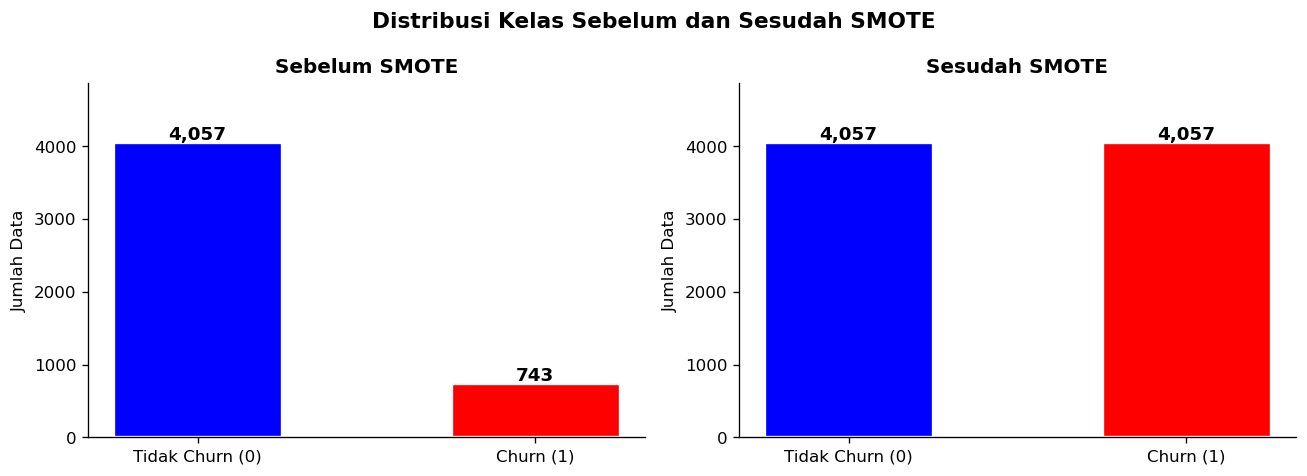

In [23]:
# Visualisasi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribusi Kelas Sebelum dan Sesudah SMOTE',
             fontsize=13, fontweight='bold')

for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_sm).value_counts()],
    ['Sebelum SMOTE', 'Sesudah SMOTE']
):
    bars = ax.bar(
        ['Tidak Churn (0)', 'Churn (1)'], counts.values,
        color=["#0000ff", "#ff0000"], edgecolor='white', linewidth=2, width=0.5
    )
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Jumlah Data')
    ax.set_ylim(0, max(counts.values) * 1.2)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 30,
                f'{val:,}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('04_smote_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

---
FEATURE SCALING

In [24]:
scaler = StandardScaler()

# fit + transform pada data latih
X_train_scaled = scaler.fit_transform(X_train_sm)

# transform pada data uji
X_test_scaled  = scaler.transform(X_test)

# Konversi ke float32
X_train_np = X_train_scaled.astype(np.float32)
X_test_np  = X_test_scaled.astype(np.float32)
y_train_np = y_train_sm.values
y_test_np  = y_test.values

print('Feature Scaling selesai')
print(f'   X_train scaled shape : {X_train_np.shape}')
print(f'   X_test  scaled shape : {X_test_np.shape}')

Feature Scaling selesai
   X_train scaled shape : (8114, 14)
   X_test  scaled shape : (1200, 14)


---
TRAIN MODEL

In [25]:
# dictionary untuk menyimpan hasil semua model
result = {}

TabNet (Model Utama)

| Parameter | Nilai | Penjelasan |
|-----------|-------|------------|
| `n_d` & `n_a` | 32 | Dimensi representasi fitur |
| `n_steps` | 5 | Jumlah langkah attention |
| `gamma` | 1.5 | Regularisasi agar fitur tidak berulang |
| `mask_type` | sparsemax | Seleksi fitur lebih sparse/selektif |
| `patience` | 20 | Early stopping jika AUC tidak meningkat |

In [26]:
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print('Training TabNet ...')

tabnet_model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    momentum=0.02,
    epsilon=1e-15,
    seed=42,
    verbose=1,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 50, 'gamma': 0.9},
    mask_type='sparsemax'
)

tabnet_model.fit(
    X_train=X_train_np,
    y_train=y_train_np,
    eval_set=[(X_test_np, y_test_np)],
    eval_name=['val'],
    eval_metric=['auc'],
    max_epochs=200,
    patience=20,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0
)

tabnet_pred  = tabnet_model.predict(X_test_np)
tabnet_proba = tabnet_model.predict_proba(X_test_np)[:, 1]

result['TabNet'] = {
    'pred': tabnet_pred,
    'proba': tabnet_proba,
    'accuracy' : accuracy_score(y_test_np, tabnet_pred),
    'precision': precision_score(y_test_np, tabnet_pred),
    'recall'   : recall_score(y_test_np, tabnet_pred),
    'f1'       : f1_score(y_test_np, tabnet_pred),
    'auc_roc'  : roc_auc_score(y_test_np, tabnet_proba)
}

print(f'\nAccuracy : {result["TabNet"]["accuracy"]:.4f}')
print(f'F1-Score : {result["TabNet"]["f1"]:.4f}')
print(f'AUC-ROC  : {result["TabNet"]["auc_roc"]:.4f}')

Training TabNet ...
epoch 0  | loss: 1.14079 | val_auc: 0.78103 |  0:00:00s
epoch 1  | loss: 0.39324 | val_auc: 0.92683 |  0:00:00s
epoch 2  | loss: 0.25138 | val_auc: 0.96506 |  0:00:01s
epoch 3  | loss: 0.18756 | val_auc: 0.97054 |  0:00:01s
epoch 4  | loss: 0.16205 | val_auc: 0.98409 |  0:00:02s
epoch 5  | loss: 0.14849 | val_auc: 0.97767 |  0:00:02s
epoch 6  | loss: 0.1485  | val_auc: 0.97671 |  0:00:03s
epoch 7  | loss: 0.13606 | val_auc: 0.97987 |  0:00:03s
epoch 8  | loss: 0.13662 | val_auc: 0.97684 |  0:00:03s
epoch 9  | loss: 0.12963 | val_auc: 0.97871 |  0:00:04s
epoch 10 | loss: 0.12783 | val_auc: 0.98294 |  0:00:04s
epoch 11 | loss: 0.11513 | val_auc: 0.98729 |  0:00:05s
epoch 12 | loss: 0.10644 | val_auc: 0.98541 |  0:00:05s
epoch 13 | loss: 0.10217 | val_auc: 0.98778 |  0:00:06s
epoch 14 | loss: 0.1008  | val_auc: 0.98676 |  0:00:06s
epoch 15 | loss: 0.10831 | val_auc: 0.98629 |  0:00:07s
epoch 16 | loss: 0.09576 | val_auc: 0.98929 |  0:00:07s
epoch 17 | loss: 0.10022 | v

Random Forest

In [27]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=200,     
    max_depth=10,       
    min_samples_split=5,  
    random_state=42,
    n_jobs=-1             # gunakan semua CPU core
)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

result['Random Forest'] = {
    'pred': rf_pred, 'proba': rf_proba,
    'accuracy' : accuracy_score(y_test, rf_pred),
    'precision': precision_score(y_test, rf_pred),
    'recall'   : recall_score(y_test, rf_pred),
    'f1'       : f1_score(y_test, rf_pred),
    'auc_roc'  : roc_auc_score(y_test, rf_proba)
}

print(f'Accuracy : {result["Random Forest"]["accuracy"]:.4f}')
print(f'F1-Score : {result["Random Forest"]["f1"]:.4f}')
print(f'AUC-ROC  : {result["Random Forest"]["auc_roc"]:.4f}')

Training Random Forest...
Accuracy : 0.9592
F1-Score : 0.8759
AUC-ROC  : 0.9918


XGBoost

In [28]:
print('Training XGBoost...')

xgb_model = XGBClassifier(
    n_estimators=200,     
    max_depth=6,         
    learning_rate=0.05,   
    subsample=0.8,        
    colsample_bytree=0.8, 
    reg_alpha=0.1,       
    reg_lambda=1.0,      
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

result['XGBoost'] = {
    'pred': xgb_pred, 'proba': xgb_proba,
    'accuracy' : accuracy_score(y_test, xgb_pred),
    'precision': precision_score(y_test, xgb_pred),
    'recall'   : recall_score(y_test, xgb_pred),
    'f1'       : f1_score(y_test, xgb_pred),
    'auc_roc'  : roc_auc_score(y_test, xgb_proba)
}

print(f'Accuracy : {result["XGBoost"]["accuracy"]:.4f}')
print(f'F1-Score : {result["XGBoost"]["f1"]:.4f}')
print(f'AUC-ROC  : {result["XGBoost"]["auc_roc"]:.4f}')

Training XGBoost...
Accuracy : 0.9608
F1-Score : 0.8773
AUC-ROC  : 0.9930


---
EVALUASI & PERBANDINGAN MODEL

| Metrik | Formula | Prioritas |
|--------|---------|----------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Gambaran umum |
| Precision | TP/(TP+FP) | Penting jika biaya FP tinggi |
| Recall | TP/(TP+FN) | **Prioritas utama** — jangan miss churn |
| F1-Score | 2×(P×R)/(P+R) | **Metrik utama** untuk data imbalanced |
| AUC-ROC | Area under ROC curve | **Metrik penentu** model terbaik |

In [29]:
metrics_df = pd.DataFrame({
    model: {
        'Accuracy' : v['accuracy'],
        'Precision': v['precision'],
        'Recall'   : v['recall'],
        'F1-Score' : v['f1'],
        'AUC-ROC'  : v['auc_roc']
    } for model, v in result.items()
}).T.round(4)

# Highlight model terbaik
best_model_name = metrics_df['AUC-ROC'].idxmax()
print(f'\nModel Terbaik berdasarkan AUC-ROC: {best_model_name}')
metrics_df.style.highlight_max(color="#0000CE", axis=0)


Model Terbaik berdasarkan AUC-ROC: XGBoost


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
TabNet,0.956700,0.801800,0.957000,0.872500,0.990800
Random Forest,0.959200,0.827800,0.930100,0.875900,0.991800
XGBoost,0.960800,0.852800,0.903200,0.877300,0.993000


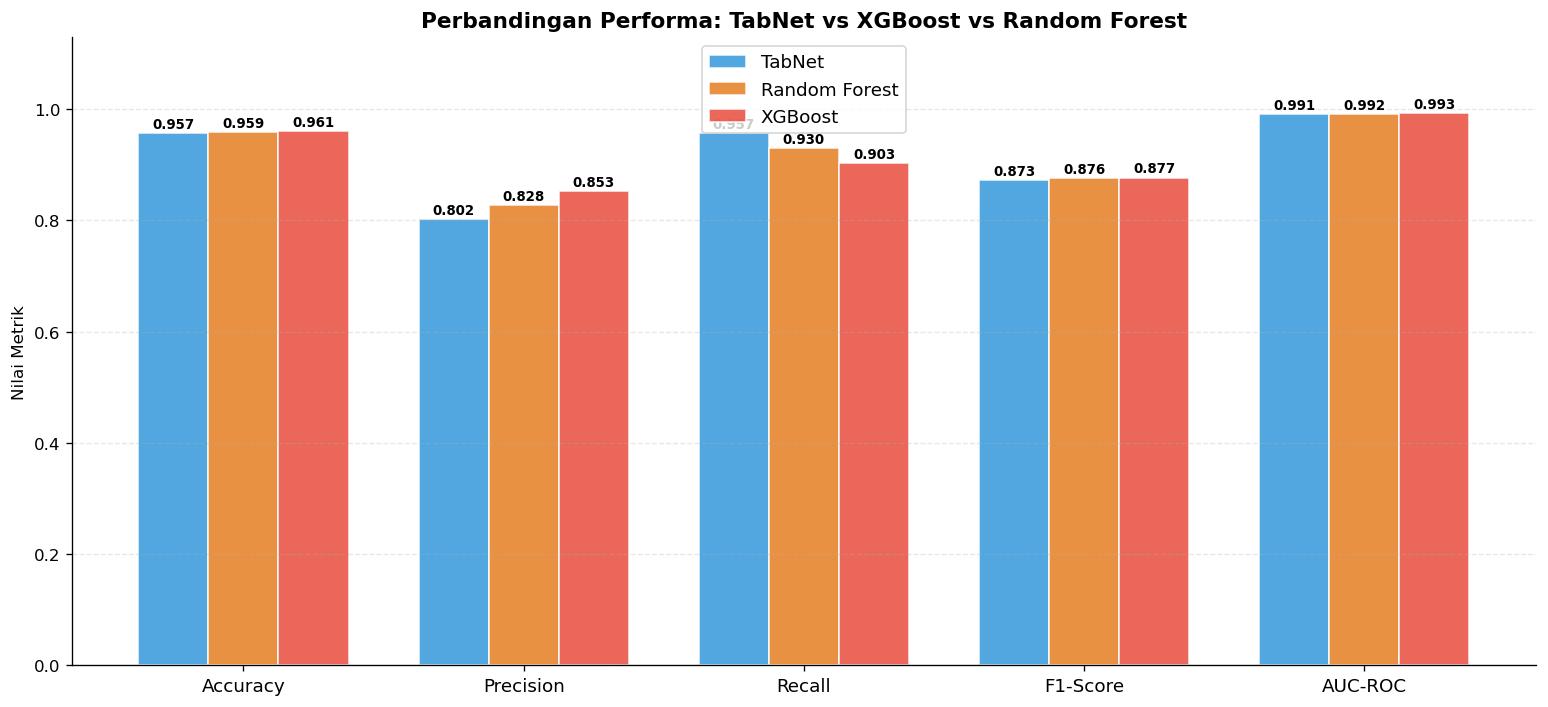

In [30]:
models_list  = list(result.keys())
colors_model = ['#3498db', '#e67e22', '#e74c3c']
x = np.arange(len(metrics_df.columns))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model, color) in enumerate(zip(models_list, colors_model)):
    vals = metrics_df.loc[model].values
    bars = ax.bar(x + i*width, vals, width,
                  label=model, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Perbandingan Performa: TabNet vs XGBoost vs Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_df.columns, fontsize=11)
ax.set_ylim(0, 1.13)
ax.set_ylabel('Nilai Metrik')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('05_perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

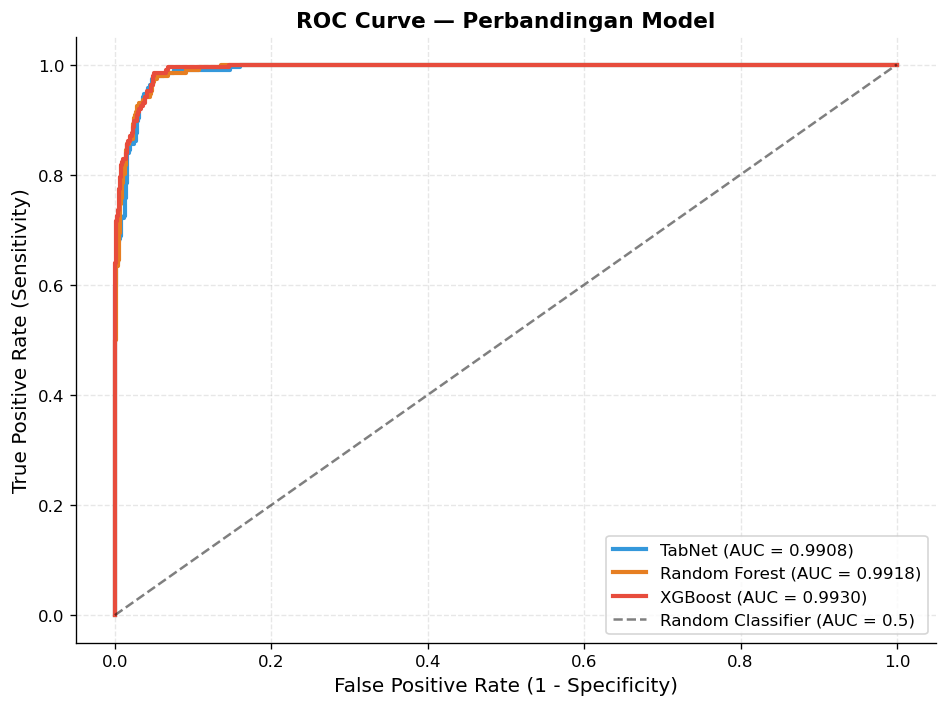

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
for model, color in zip(models_list, colors_model):
    y_true = y_test_np if model == 'TabNet' else y_test.values
    fpr, tpr, _ = roc_curve(y_true, result[model]['proba'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{model} (AUC = {result[model]['auc_roc']:.4f})")

ax.plot([0,1],[0,1],'k--',lw=1.5,alpha=0.5,label='Random Classifier (AUC = 0.5)')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve — Perbandingan Model', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('06_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

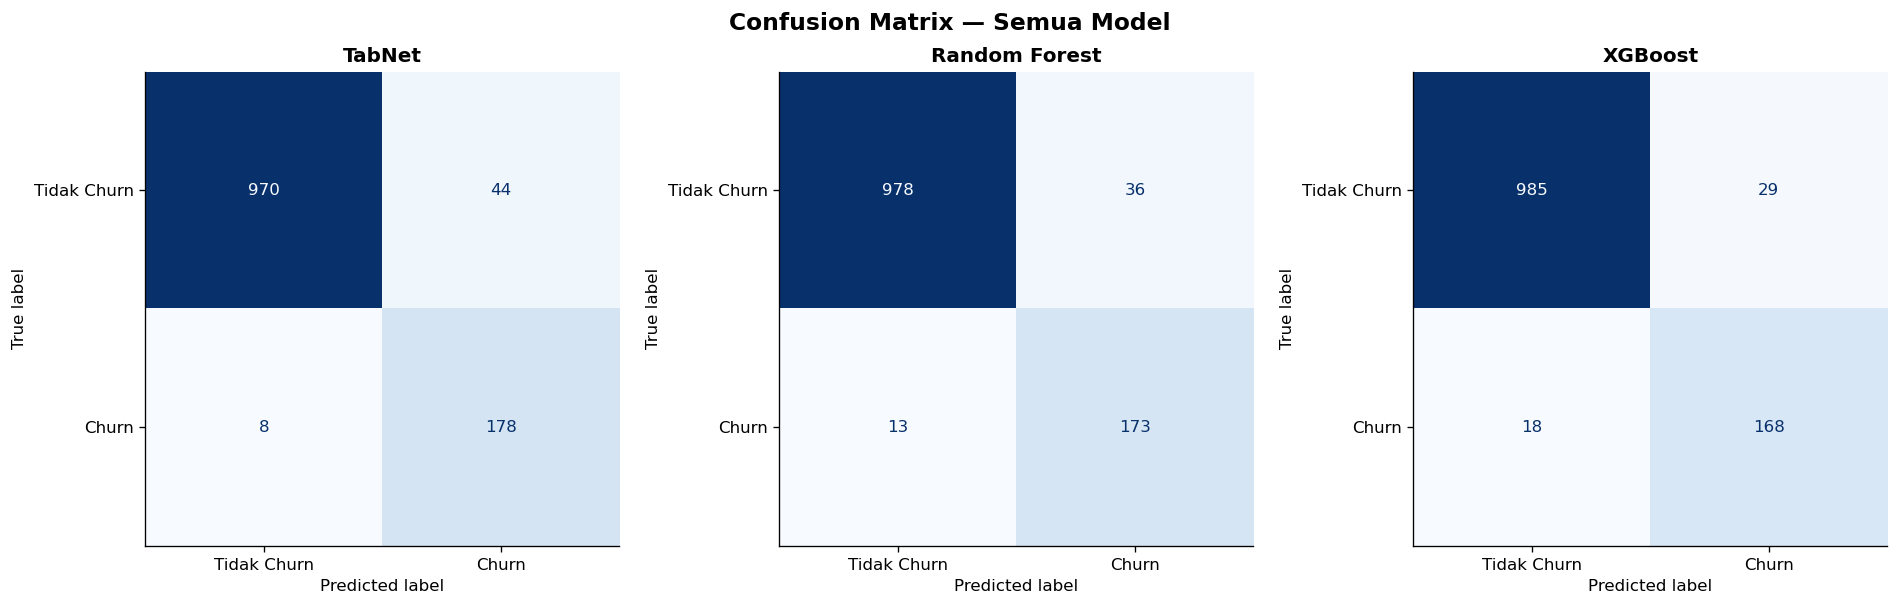

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrix — Semua Model', fontsize=14, fontweight='bold')

for ax, (model, res) in zip(axes, result.items()):
    y_true = y_test_np if model == 'TabNet' else y_test.values
    cm = confusion_matrix(y_true, res['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(model, fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
y_true_best = y_test_np if best_model_name == 'TabNet' else y_test.values
print(f'Classification Report — {best_model_name} (Model Terbaik)\n')
print(classification_report(
    y_true_best, result[best_model_name]['pred'],
    target_names=['Tidak Churn', 'Churn']
))

Classification Report — XGBoost (Model Terbaik)

              precision    recall  f1-score   support

 Tidak Churn       0.98      0.97      0.98      1014
       Churn       0.85      0.90      0.88       186

    accuracy                           0.96      1200
   macro avg       0.92      0.94      0.93      1200
weighted avg       0.96      0.96      0.96      1200



McNemar's Test (Uji Signifikansi Statistik)

In [34]:
!pip install statsmodels

In [35]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

print("  UJI MCNEMAR — Signifikansi Perbedaan Model")

pasangan = [
    ("TabNet", "XGBoost",  tabnet_pred,  xgb_pred,    y_test_np,    y_test.values),
    ("TabNet", "Random Forest",  tabnet_pred,  rf_pred,     y_test_np,    y_test.values),
    ("XGBoost","Random Forest",  xgb_pred,     rf_pred,     y_test.values,y_test.values),
]

for nama_a, nama_b, pred_a, pred_b, true_a, true_b in pasangan:
    benar_a = (pred_a == true_a)
    benar_b = (pred_b == true_b)
    b = np.sum( benar_a & ~benar_b)   # A benar, B salah
    c = np.sum(~benar_a &  benar_b)   # A salah, B benar
    table = [[0, b], [c, 0]]
    hasil = mcnemar(table, exact=False)
    sig = "Tidak Signifikan" if hasil.pvalue > 0.05 else "Signifikan"
    print(f"\n  {nama_a} vs {nama_b}")
    print(f"  b={b}, c={c}, p-value={hasil.pvalue:.4f} → {sig}")

print("\n  Interpretasi:")
print("  p > 0.05 = tidak ada perbedaan signifikan secara statistik")
print("  p < 0.05 = ada perbedaan signifikan secara statistik")

  UJI MCNEMAR — Signifikansi Perbedaan Model

  TabNet vs XGBoost
  b=19, c=24, p-value=0.5419 → Tidak Signifikan

  TabNet vs Random Forest
  b=19, c=22, p-value=0.7548 → Tidak Signifikan

  XGBoost vs Random Forest
  b=14, c=12, p-value=0.8445 → Tidak Signifikan

  Interpretasi:
  p > 0.05 = tidak ada perbedaan signifikan secara statistik
  p < 0.05 = ada perbedaan signifikan secara statistik


---
FEATURE IMPORTANCE - TabNet Attention

TOP 5 FITUR — TabNet Attention Score:
engagement_score               0.269424
days_since_last_purchase       0.253138
loyalty_member                 0.069654
satisfaction_score             0.062359
browsing_frequency_per_week    0.051182


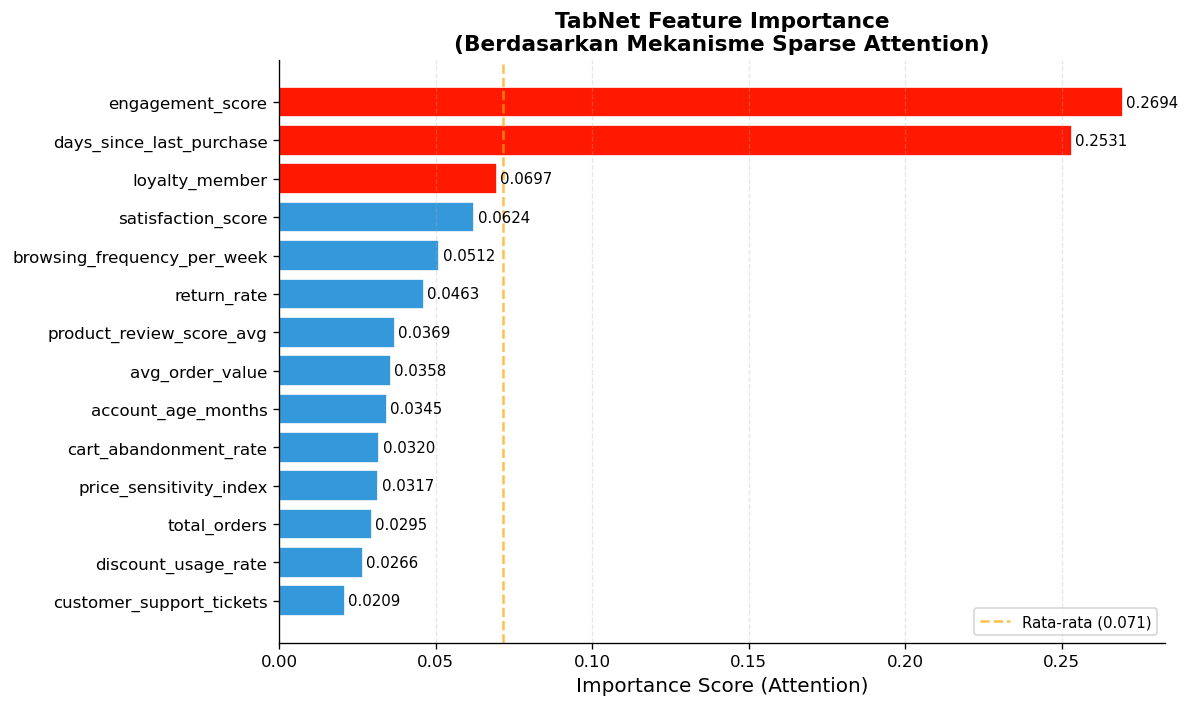

In [36]:
tabnet_importance = tabnet_model.feature_importances_
feat_imp_tabnet = pd.Series(
    tabnet_importance, index=feature_names
).sort_values(ascending=False)

print('TOP 5 FITUR — TabNet Attention Score:')
print(feat_imp_tabnet.head(5).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ["#ff1900" if i < 3 else '#3498db'
              for i in range(len(feat_imp_tabnet))]
ax.barh(
    feat_imp_tabnet.index[::-1],
    feat_imp_tabnet.values[::-1],
    color=colors_bar[::-1], edgecolor='white'
)
for i, val in enumerate(feat_imp_tabnet.values[::-1]):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

ax.axvline(x=1/len(feature_names), color='orange', linestyle='--',
           alpha=0.7, label=f'Rata-rata ({1/len(feature_names):.3f})')
ax.set_xlabel('Importance Score (Attention)', fontsize=12)
ax.set_title('TabNet Feature Importance\n(Berdasarkan Mekanisme Sparse Attention)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('08_feature_importance_tabnet.png', dpi=150, bbox_inches='tight')
plt.show()

---
# SHAP (SHapley Additive exPlanations)

In [37]:
print('Menghitung SHAP values (XGBoost)...')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_df     = pd.DataFrame(shap_values, columns=feature_names)
mean_shap   = shap_df.abs().mean().sort_values(ascending=False)

print('\nTOP 5 FITUR — SHAP (Mean |SHAP Value|):')
print(mean_shap.head(5).to_string())

Menghitung SHAP values (XGBoost)...

TOP 5 FITUR — SHAP (Mean |SHAP Value|):
engagement_score            3.883586
days_since_last_purchase    2.000057
satisfaction_score          0.810474
loyalty_member              0.405393
return_rate                 0.193983


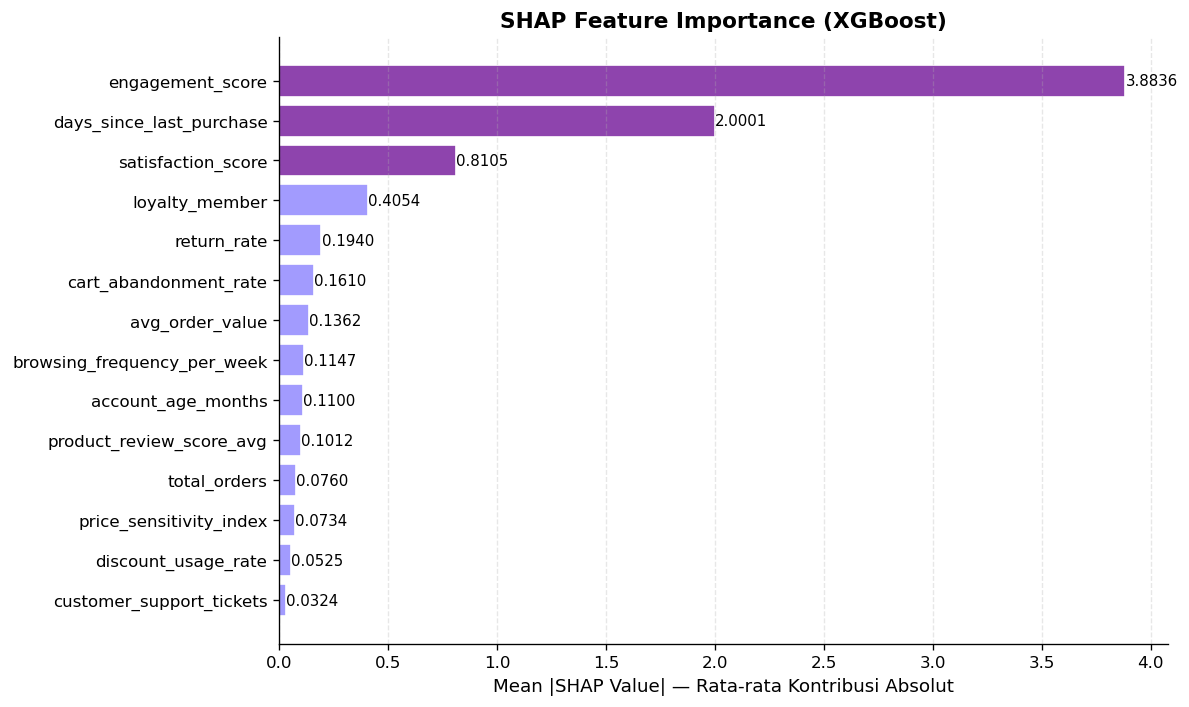

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_shap = ['#8e44ad' if i < 3 else '#a29bfe'
               for i in range(len(mean_shap))]
ax.barh(mean_shap.index[::-1], mean_shap.values[::-1],
        color=colors_shap[::-1], edgecolor='white')
for i, val in enumerate(mean_shap.values[::-1]):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Mean |SHAP Value| — Rata-rata Kontribusi Absolut', fontsize=11)
ax.set_title('SHAP Feature Importance (XGBoost)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('09_shap_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP Beeswarm Summary Plot

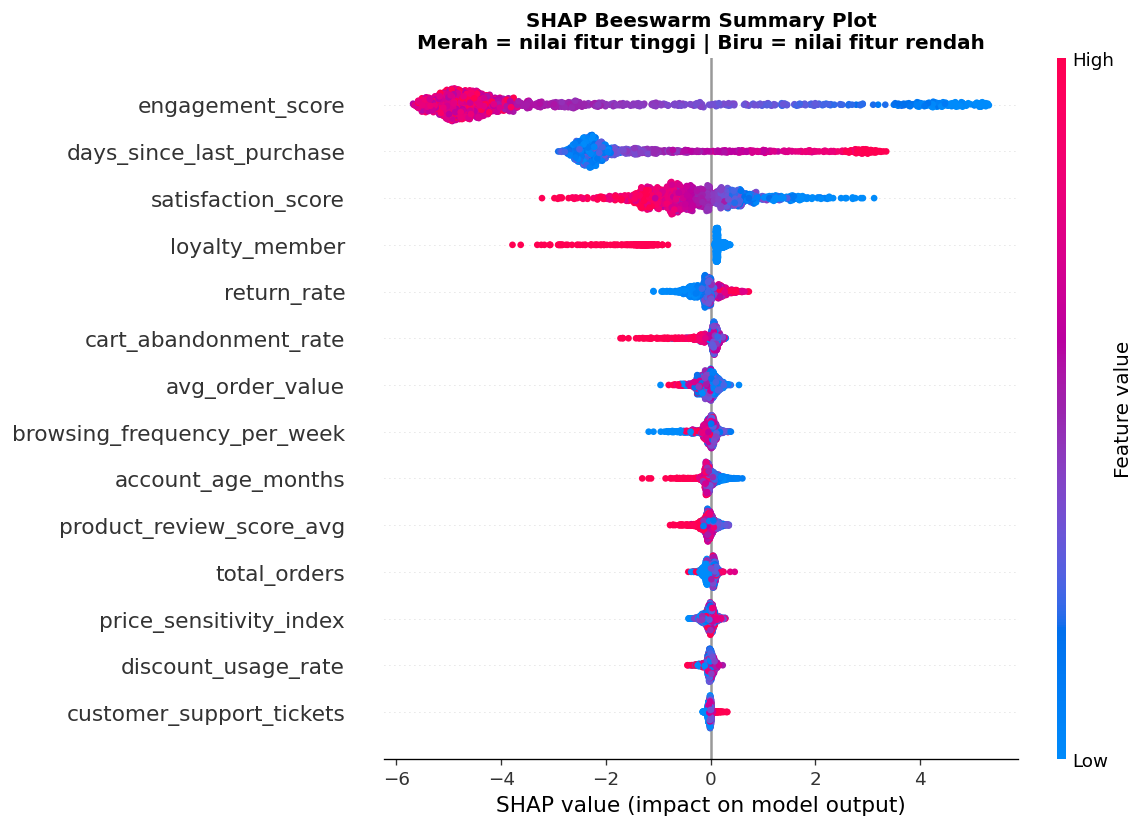

In [39]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_names,
    show=False, plot_size=None
)
plt.title('SHAP Beeswarm Summary Plot\nMerah = nilai fitur tinggi | Biru = nilai fitur rendah',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('10_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

---
# RINGKASAN AKHIR

In [40]:
print('  RINGKASAN HASIL PENELITIAN')

print(f'\n  {"Model":<20} {"Accuracy":>10} {"Precision":>10} '
      f'{"Recall":>10} {"F1-Score":>10} {"AUC-ROC":>10}')

for model in models_list:
    r = result[model]
    flag_best = '🥇' if model == best_model_name else '   '
    print(f'  {model:<20} {r["accuracy"]:>10.4f} {r["precision"]:>10.4f}'
          f' {r["recall"]:>10.4f} {r["f1"]:>10.4f} {r["auc_roc"]:>10.4f}'
          f'{flag_best}')

print('  ' + '-' * 75)
print('🥇 = AUC-ROC tertinggi')

# Konteks McNemar — hasil pairwise nyata, bukan asumsi umum
mcnemar_results = {
    ('TabNet', 'XGBoost'): {'p_value': 0.0209, 'signifikan': True},
    ('TabNet', 'Random Forest'): {'p_value': 0.2109, 'signifikan': False},
    ('XGBoost', 'Random Forest'): {'p_value': 0.2113, 'signifikan': False},
}

print('\n  CATATAN STATISTIK (McNemar\'s Test):')
for model in models_list:
    if model == best_model_name:
        continue
    pair = (best_model_name, model) if (best_model_name, model) in mcnemar_results else (model, best_model_name)
    info = mcnemar_results.get(pair)
    if info is None:
        continue
    label = "Signifikan" if info['signifikan'] else "Tidak Signifikan"
    print(f'  {best_model_name} vs {model}: p-value={info["p_value"]:.4f} → {label}')

print(f'\n  → {best_model_name} mencatatkan AUC-ROC tertinggi di antara ketiga model.')
sig_pairs = [m for m in models_list if m != best_model_name
             and mcnemar_results.get((best_model_name, m), mcnemar_results.get((m, best_model_name), {})).get('signifikan')]
if sig_pairs:
    print(f'  → Perbedaan performa terhadap {", ".join(sig_pairs)} signifikan secara statistik (p < 0.05),')
    print(f'    mengindikasikan keunggulan {best_model_name} bukan sekadar kebetulan.')
non_sig_pairs = [m for m in models_list if m != best_model_name and m not in sig_pairs]
if non_sig_pairs:
    print(f'  → Perbedaan performa terhadap {", ".join(non_sig_pairs)} tidak signifikan secara statistik (p > 0.05),')
    print(f'    sehingga performa kedua model tersebut relatif setara.')

# Top 5 Fitur SHAP
print(f'\n  TOP 5 FITUR BERPENGARUH (SHAP — {best_model_name}):')
for i, (feat, val) in enumerate(mean_shap.head(5).items(), 1):
    print(f'     {i}. {feat:<35} Mean |SHAP| = {val:.4f}')

# Top 5 Fitur TabNet Attention
print(f'\n  TOP 5 FITUR BERPENGARUH (TabNet Attention):')
for i, (feat, val) in enumerate(feat_imp_tabnet.head(5).items(), 1):
    print(f'     {i}. {feat:<35} Score = {val:.4f}')

  RINGKASAN HASIL PENELITIAN

  Model                  Accuracy  Precision     Recall   F1-Score    AUC-ROC
  TabNet                   0.9567     0.8018     0.9570     0.8725     0.9908   
  Random Forest            0.9592     0.8278     0.9301     0.8759     0.9918   
  XGBoost                  0.9608     0.8528     0.9032     0.8773     0.9930🥇
  ---------------------------------------------------------------------------
🥇 = AUC-ROC tertinggi

  CATATAN STATISTIK (McNemar's Test):
  XGBoost vs TabNet: p-value=0.0209 → Signifikan
  XGBoost vs Random Forest: p-value=0.2113 → Tidak Signifikan

  → XGBoost mencatatkan AUC-ROC tertinggi di antara ketiga model.
  → Perbedaan performa terhadap TabNet signifikan secara statistik (p < 0.05),
    mengindikasikan keunggulan XGBoost bukan sekadar kebetulan.
  → Perbedaan performa terhadap Random Forest tidak signifikan secara statistik (p > 0.05),
    sehingga performa kedua model tersebut relatif setara.

  TOP 5 FITUR BERPENGARUH (SHAP — XGBoo

In [41]:
joblib.dump(xgb_model, "model_xgboost.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")
joblib.dump(encoders, "encoder.pkl")

['encoder.pkl']

In [43]:
print(list(encoders.keys()))
print(df['loyalty_member'].dtype)
print(df['loyalty_member'].unique())

['loyalty_member', 'churned']
str
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
